<a href="https://colab.research.google.com/github/mancinigabriel/tcc-pece-assin2-llm-challenges/blob/main/notebooks/analise_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Preparando ambiente

In [2]:
!git clone https://github.com/mancinigabriel/tcc-pece-assin2-llm-challenges.git

Cloning into 'tcc-pece-assin2-llm-challenges'...
remote: Enumerating objects: 256, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 256 (delta 35), reused 12 (delta 12), pack-reused 211 (from 1)
Receiving objects: 100% (256/256), 523.70 KiB | 10.47 MiB/s, done.
Resolving deltas: 100% (149/149), done.


In [3]:
import sys
import os

PROJECT_ROOT = os.path.abspath('/content/tcc-pece-assin2-llm-challenges')

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [4]:
import pandas as pd
import random
import re
import time
import math
import os
import json
from src import data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import math

def categorizar_1a5(valor: float) -> int:
    if not 1.0 <= valor <= 5.0:
        raise ValueError("O valor deve estar entre 1 e 5.")

    return min(5, math.ceil(valor))

In [6]:
dados_limpos = data.gera_df()

In [7]:
dados_limpos.describe()
dados_limpos['entailment_judgment_label'] = dados_limpos['entailment_judgment'].map({0: 'Not Entailment', 1: 'Entailment'})
dados_limpos['cat_sim'] = dados_limpos['relatedness_score'].apply(categorizar_1a5)

In [8]:
qtd_por_julg = dados_limpos.groupby(['entailment_judgment_label'])['sentence_pair_id'].count().reset_index()
qtd_por_julg.columns = ['Julgamento', 'qtd']

qtd_cat_sim = dados_limpos.groupby(['cat_sim'])['sentence_pair_id'].count().reset_index()
qtd_cat_sim.columns = ['Categoria de Similaridade', 'qtd']

In [9]:
qtd_por_julg = qtd_por_julg.pivot_table(
    columns='Julgamento',
    values='qtd'
).round(4)

qtd_cat_sim = qtd_cat_sim.pivot_table(
    columns='Categoria de Similaridade',
    values='qtd'
).round(4)



In [46]:
import os
import json

log_folder_path = '/content/drive/MyDrive/Mestrado/TCC Pós/Dados/logs/assin2'

all_logs = []

if os.path.exists(log_folder_path):
    for filename in os.listdir(log_folder_path):
        if filename.endswith('.json'):
            filepath = os.path.join(log_folder_path, filename)
            try:
                with open(filepath, 'r') as f:
                    log_data = json.load(f)
                    all_logs.append(log_data)
                print(f"Successfully read {filename}")
            except json.JSONDecodeError:
                print(f"Error decoding JSON from {filename}")
            except Exception as e:
                print(f"Error reading {filename}: {e}")
else:
    print(f"The directory {log_folder_path} does not exist.")

df_logs = pd.DataFrame([log['log'] for log in all_logs])

Successfully read log_bode_7b_20260112_023227.json
Successfully read log_mistral8b_reasoning_20260112_025553.json
Successfully read log_qwen3_4b_instruct_20260112_030112.json
Successfully read log_sabia-7b_20260112_033330.json
Successfully read log_gaia_20260112_033534.json
Successfully read log_gemma_2_2b_it_20260112_033805.json
Successfully read log_qwen3_4b_thinking_20260112_034407.json
Successfully read log_gemma_2_9b_it_20260112_042832.json
Successfully read log_mistral3b_instruct_fp8_20260114_153353.json
Successfully read log_mistral8b_instruct_fp8_20260114_182551.json
Successfully read log_mistral3b_reasoning_20260116_081724.json


In [47]:
df_execution = pd.json_normalize(df_logs['execution'])
df_generation = pd.json_normalize(df_logs['generation'])
df_metrics_main = pd.json_normalize(df_logs['metrics'])
df_metrics_consistency = pd.json_normalize(df_logs['metrics'].apply(lambda x: x['consistência']))

df_execution.columns = ['execution_' + col for col in df_execution.columns]
df_generation.columns = ['generation_' + col for col in df_generation.columns]
df_metrics_main.columns = ['metrics_' + col for col in df_metrics_main.columns]
df_metrics_consistency.columns = ['metrics_consistency_' + col for col in df_metrics_consistency.columns]

df_logs = pd.concat([
    df_logs.drop(columns=['execution', 'generation', 'metrics']),
    df_execution,
    df_generation,
    df_metrics_main.drop(columns=['metrics_consistência'], errors='ignore'),
    df_metrics_consistency
], axis=1)

In [44]:
data_folder_path = '/content/drive/MyDrive/Mestrado/TCC Pós/Dados/completos'

dataframes = {}

if os.path.exists(data_folder_path):
    for filename in os.listdir(data_folder_path):
        if filename.endswith('.csv') and 'consistencia' not in filename:
            filepath = os.path.join(data_folder_path, filename)
            try:
                df_name = filename.replace('.csv', '') # Use filename as key
                dataframes[df_name] = pd.read_csv(filepath)
                dataframes[df_name]['match'] = (
                  dataframes[df_name]['entailment_judgment']
                  == dataframes[df_name]['pred_tratado']).astype(int)
                dataframes[df_name]['cat_sim'] = dataframes[df_name]['relatedness_score'].apply(categorizar_1a5)
                print(f"Successfully loaded '{filename}' into DataFrame '{df_name}'.")
            except Exception as e:
                print(f"Error loading '{filename}': {e}")
else:
    print(f"The directory '{data_folder_path}' does not exist.")

Successfully loaded 'dados_bode_7b.csv' into DataFrame 'dados_bode_7b'.
Successfully loaded 'dados_mistral8b_reasoning.csv' into DataFrame 'dados_mistral8b_reasoning'.
Successfully loaded 'dados_qwen3_4b_instruct.csv' into DataFrame 'dados_qwen3_4b_instruct'.
Successfully loaded 'dados_sabia-7b.csv' into DataFrame 'dados_sabia-7b'.
Successfully loaded 'dados_gaia.csv' into DataFrame 'dados_gaia'.
Successfully loaded 'dados_gemma_2_2b_it.csv' into DataFrame 'dados_gemma_2_2b_it'.
Successfully loaded 'dados_qwen3_4b_thinking.csv' into DataFrame 'dados_qwen3_4b_thinking'.
Successfully loaded 'dados_gemma_2_9b_it.csv' into DataFrame 'dados_gemma_2_9b_it'.
Successfully loaded 'dados_mistral3b_instruct_fp8.csv' into DataFrame 'dados_mistral3b_instruct_fp8'.
Successfully loaded 'dados_mistral8b_instruct_fp8.csv' into DataFrame 'dados_mistral8b_instruct_fp8'.
Successfully loaded 'dados_mistral3b_reasoning.csv' into DataFrame 'dados_mistral3b_reasoning'.


In [13]:
qtd_por_julg

Julgamento,Entailment,Not Entailment
qtd,4634.0,4670.0


In [14]:
qtd_cat_sim

Categoria de Similaridade,1,2,3,4,5
qtd,198.0,420.0,1144.0,2875.0,4667.0


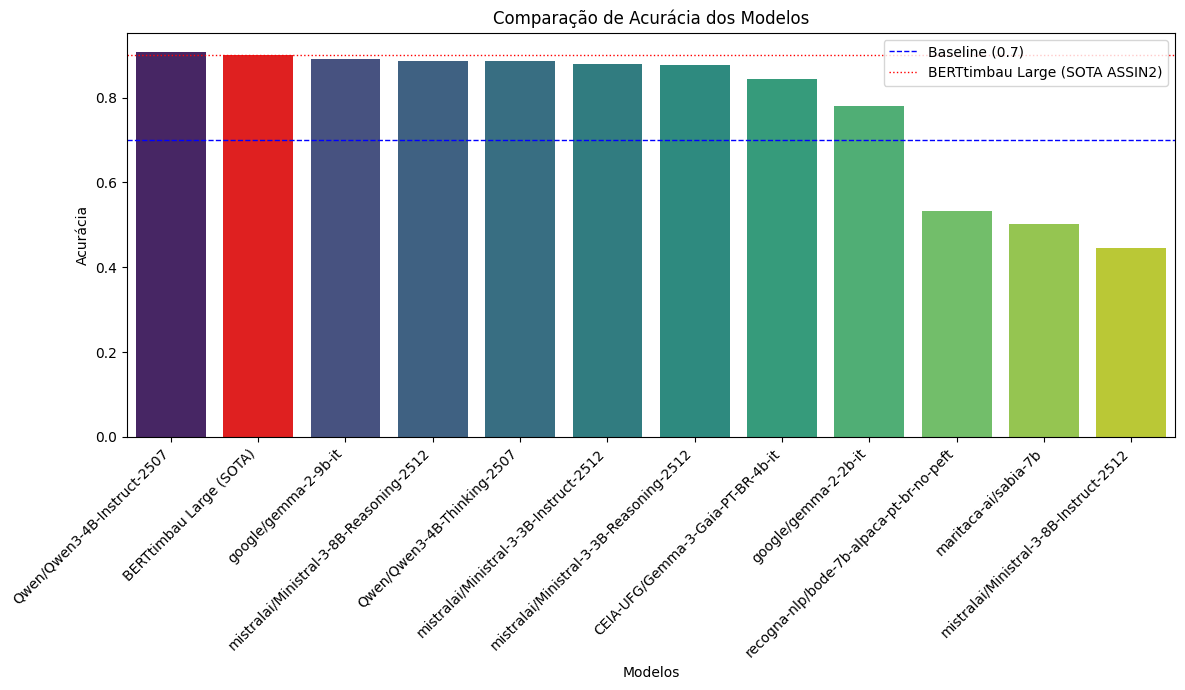

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create a temporary DataFrame to hold the original df_logs data for plotting
# and ensure any modifications are local to this plotting operation.
df_logs_plot_data = df_logs.copy()

# Prepare the data for the new model 'Bertimbau'
# Create a dictionary representing the new row, ensuring it has all the columns
# present in the original df_logs, filling non-essential ones with NaN.
bertimbau_data = {
    'model': 'BERTtimbau Large (SOTA)',
    'metrics_acurácia': 0.90,
    # Fill with NaN for non-relevant columns to match df_logs structure
    'gpu': np.nan,
    'quantized': np.nan,
    'execution_inicio': pd.NaT,
    'execution_inicio_teste_consistencia': pd.NaT,
    'execution_fim_teste_consistencia': pd.NaT,
    'execution_fim': pd.NaT,
    'generation_temperature': np.nan,
    'generation_top_p': np.nan,
    'generation_top_k': np.nan,
    'generation_max_output_tokens': np.nan,
    'metrics_consistência.mean_consistency': np.nan,
    'metrics_consistência.std_consistency': np.nan
}
# Create a DataFrame from the new row
new_bertimbau_df = pd.DataFrame([bertimbau_data])

# Concatenate the new model's data with the existing logs
df_logs_extended = pd.concat([df_logs_plot_data, new_bertimbau_df], ignore_index=True)

# Sort the extended DataFrame by accuracy for visualization
df_logs_sorted_extended = df_logs_extended.sort_values(by='metrics_acurácia', ascending=False)

# Define a custom color palette for highlighting 'Bertimbau'
# Generate viridis colors for all bars based on their sorted order
total_bars = len(df_logs_sorted_extended)
viridis_colors_map = sns.color_palette('viridis', n_colors=total_bars)

bar_colors = []
for i, model_name in enumerate(df_logs_sorted_extended['model']):
    if model_name == 'BERTtimbau Large (SOTA)':
        bar_colors.append('red') # Highlight color for Bertimbau
    else:
        bar_colors.append(viridis_colors_map[i]) # Assign viridis color to other models


plt.figure(figsize=(12, 7))
sns.barplot(
    x='model',
    y='metrics_acurácia',
    data=df_logs_sorted_extended,
    hue='model', # Assign x variable to hue to suppress FutureWarning
    palette=bar_colors, # Use the custom color list
    legend=False # Set legend to False as suggested by FutureWarning
)

# Reference lines
plt.axhline(y=0.7, color='blue', linestyle='--', linewidth=1.0, label='Baseline (0.7)')
plt.axhline(y=0.9, color='red', linestyle=':', linewidth=1.0, label='BERTtimbau Large (SOTA ASSIN2)')

plt.xlabel('Modelos')
plt.ylabel('Acurácia')
plt.title('Comparação de Acurácia dos Modelos') # Updated title
plt.xticks(rotation=45, ha='right')

# Create a custom legend for Bertimbau and the reference lines
handles, labels = plt.gca().get_legend_handles_labels()
# Add a custom legend entry for Bertimbau
bertimbau_patch = plt.Rectangle((0,0),1,1, fc="red", edgecolor = 'none')
# handles.insert(0, bertimbau_patch) # Insert at the beginning
# labels.insert(0, 'BERTtimbau Large (0.9)') # Corresponding label

plt.legend(handles=handles, labels=labels)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3867077512.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3867077512.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


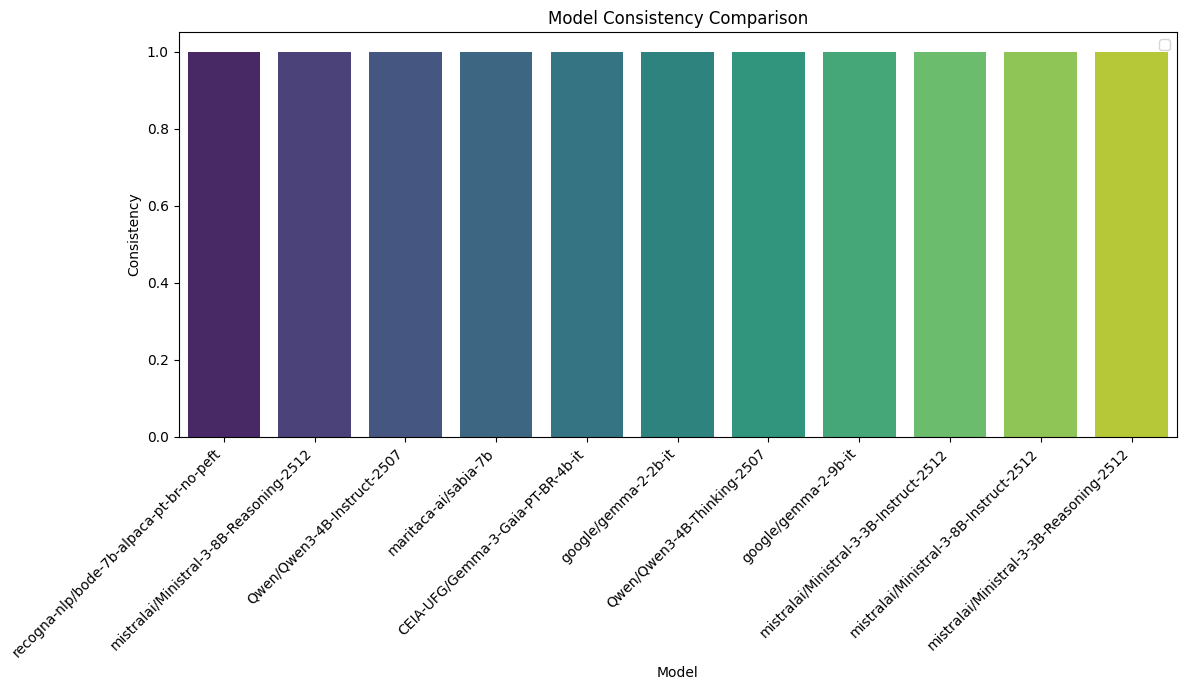

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by accuracy for better visualization
df_logs_sorted = df_logs.sort_values(by='metrics_consistência.mean_consistency', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='model',
    y='metrics_consistência.mean_consistency',
    data=df_logs_sorted,
    palette='viridis'
)

plt.xlabel('Model')
plt.ylabel('Consistency')
plt.title('Model Consistency Comparison')
plt.xticks(rotation=45, ha='right')

plt.legend()
plt.tight_layout()
plt.show()


In [17]:
combined_df_list = []

for model_name, df in dataframes.items():
    df_copy = df.copy()
    df_copy['model_name'] = model_name
    df_copy['entailment_judgment_label'] = df_copy['entailment_judgment'].map({0: 'Not Entailment', 1: 'Entailment'})
    combined_df_list.append(df_copy)

combined_df = pd.concat(combined_df_list, ignore_index=True)

mean_match_by_judgment = combined_df.groupby(['model_name', 'entailment_judgment_label'])['match'].mean().reset_index()
mean_match_by_catsim = combined_df.groupby(['model_name', 'cat_sim'])['match'].mean().reset_index()

# Create a pivot table for comparative analysis
comparison_table = mean_match_by_judgment.pivot_table(
    index='entailment_judgment_label',
    columns='model_name',
    values='match'
).round(4) * 100 # Convert to percentage and round

# Transpose the table as requested by the user
comparison_table = comparison_table.T

# Create a mapping from `df_logs['model']` (full model names) to `comparison_table.index` (simplified 'dados_' names)
model_to_df_name_map = {
    'mistralai/Ministral-3-3B-Reasoning-2512': 'dados_mistral3b_reasoning',
    'recogna-nlp/bode-7b-alpaca-pt-br-no-peft': 'dados_bode_7b',
    'mistralai/Ministral-3-8B-Reasoning-2512': 'dados_mistral8b_reasoning',
    'Qwen/Qwen3-4B-Instruct-2507': 'dados_qwen3_4b_instruct',
    'maritaca-ai/sabia-7b': 'dados_sabia-7b',
    'CEIA-UFG/Gemma-3-Gaia-PT-BR-4b-it': 'dados_gaia',
    'google/gemma-2-2b-it': 'dados_gemma_2_2b_it',
    'Qwen/Qwen3-4B-Thinking-2507': 'dados_qwen3_4b_thinking',
    'google/gemma-2-9b-it': 'dados_gemma_2_9b_it',
    'mistralai/Ministral-3-3B-Instruct-2512': 'dados_mistral3b_instruct_fp8',
    'mistralai/Ministral-3-8B-Instruct-2512': 'dados_mistral8b_instruct_fp8'
}

# Create a Series of overall accuracies, indexed by the 'dados_' names for alignment
overall_match_series = pd.Series(dtype='float64')
for full_model_name, df_name_key in model_to_df_name_map.items():
    if df_name_key in comparison_table.index: # Only process if the model is present in the comparison_table
        # Retrieve metrics_acurácia from df_logs for the current full_model_name
        accuracy = df_logs[df_logs['model'] == full_model_name]['metrics_acurácia'].iloc[0] * 100
        overall_match_series.loc[df_name_key] = accuracy
        total_match_count = comparison_table.loc[df_name_key].sum()

# Add the 'Overall Match (%)' column to comparison_table, ensuring correct alignment
comparison_table['Overall Match (%)'] = overall_match_series
comparison_table = comparison_table.sort_values(by='Overall Match (%)', ascending=False)

print("Comparative Analysis of Match by Entailment Judgment Type (in %):")
display(comparison_table)

Comparative Analysis of Match by Entailment Judgment Type (in %):


entailment_judgment_label,Entailment,Not Entailment,Overall Match (%)
model_name,,,
dados_qwen3_4b_instruct,94.69,86.87,90.767412
dados_gemma_2_9b_it,91.20,86.98,89.079966
dados_mistral8b_reasoning,93.85,83.58,88.693035
dados_qwen3_4b_thinking,96.27,80.90,88.553310
dados_mistral3b_instruct_fp8,89.94,86.08,88.005159
dados_mistral3b_reasoning,85.39,90.26,87.833190
dados_gaia,95.90,72.89,84.350817
dados_gemma_2_2b_it,95.17,60.94,77.987962
dados_bode_7b,99.96,7.17,53.385641


In [18]:
comparison_table_catsim = mean_match_by_catsim.pivot_table(
    index='cat_sim',
    columns='model_name',
    values='match'
).round(4) * 100

comparison_table_catsim = comparison_table_catsim.T

comparison_table_catsim['Overall Match (%)'] = overall_match_series
comparison_table_catsim = comparison_table_catsim.sort_values(by='Overall Match (%)', ascending=False)

print("Comparative Analysis of Match by Cat_Sim Type (in %):")
display(comparison_table_catsim)

Comparative Analysis of Match by Cat_Sim Type (in %):


cat_sim,1,2,3,4,5,Overall Match (%)
model_name,,,,,,
dados_qwen3_4b_instruct,98.48,93.33,92.40,88.31,91.32,90.767412
dados_gemma_2_9b_it,97.47,95.48,90.73,86.68,89.22,89.079966
dados_mistral8b_reasoning,94.95,91.67,89.34,85.67,89.87,88.693035
dados_qwen3_4b_thinking,99.49,96.19,91.17,83.48,89.89,88.553310
dados_mistral3b_instruct_fp8,95.45,95.71,90.82,85.53,87.83,88.005159
dados_mistral3b_reasoning,93.43,94.05,93.01,88.28,85.49,87.833190
dados_gaia,100.00,95.71,82.34,75.30,88.73,84.350817
dados_gemma_2_2b_it,98.48,82.62,69.32,65.91,86.27,77.987962
dados_bode_7b,10.10,6.43,7.26,27.86,86.48,53.385641


In [30]:
import os
import json

log_folder_path = '/content/drive/MyDrive/Mestrado/TCC Pós/Dados/logs/dados sinteticos'

all_logs = []

if os.path.exists(log_folder_path):
    for filename in os.listdir(log_folder_path):
        if filename.endswith('.json'):
            filepath = os.path.join(log_folder_path, filename)
            try:
                with open(filepath, 'r') as f:
                    log_data = json.load(f)
                    all_logs.append(log_data)
                print(f"Successfully read {filename}")
            except json.JSONDecodeError:
                print(f"Error decoding JSON from {filename}")
            except Exception as e:
                print(f"Error reading {filename}: {e}")
else:
    print(f"The directory {log_folder_path} does not exist.")

df_logs = pd.DataFrame([log['log'] for log in all_logs])

Successfully read log_gemma_2_2b_it_df_sintetico_20260117_172559.json
Successfully read log_gemma_2_9b_it_df_sintetico_20260117_172933.json
Successfully read log_sabia-7b_df_sintetico_20260117_173652.json
Successfully read log_bode_7b_df_sintetico_20260117_173750.json
Successfully read log_gaia_df_sintetico_20260117_174050.json
Successfully read log_mistral3b_instruct_fp8_df_sintetico_20260117_174320.json
Successfully read log_mistral8b_instruct_fp8_df_sintetico_20260117_174507.json
Successfully read log_qwen3_4b_instruct_df_sintetico_20260117_174805.json
Successfully read log_qwen3_4b_thinking_df_sintetico_20260117_174914.json
Successfully read log_mistral3b_reasoning_df_sintetico_20260117_181517.json
Successfully read log_mistral8b_reasoning_df_sintetico_20260117_181756.json


In [31]:
df_execution = pd.json_normalize(df_logs['execution'])
df_generation = pd.json_normalize(df_logs['generation'])
df_metrics_main = pd.json_normalize(df_logs['metrics'])

df_execution.columns = ['execution_' + col for col in df_execution.columns]
df_generation.columns = ['generation_' + col for col in df_generation.columns]
df_metrics_main.columns = ['metrics_' + col for col in df_metrics_main.columns]

df_logs = pd.concat([
    df_logs.drop(columns=['execution', 'generation', 'metrics']),
    df_execution,
    df_generation,
    df_metrics_main
], axis=1)

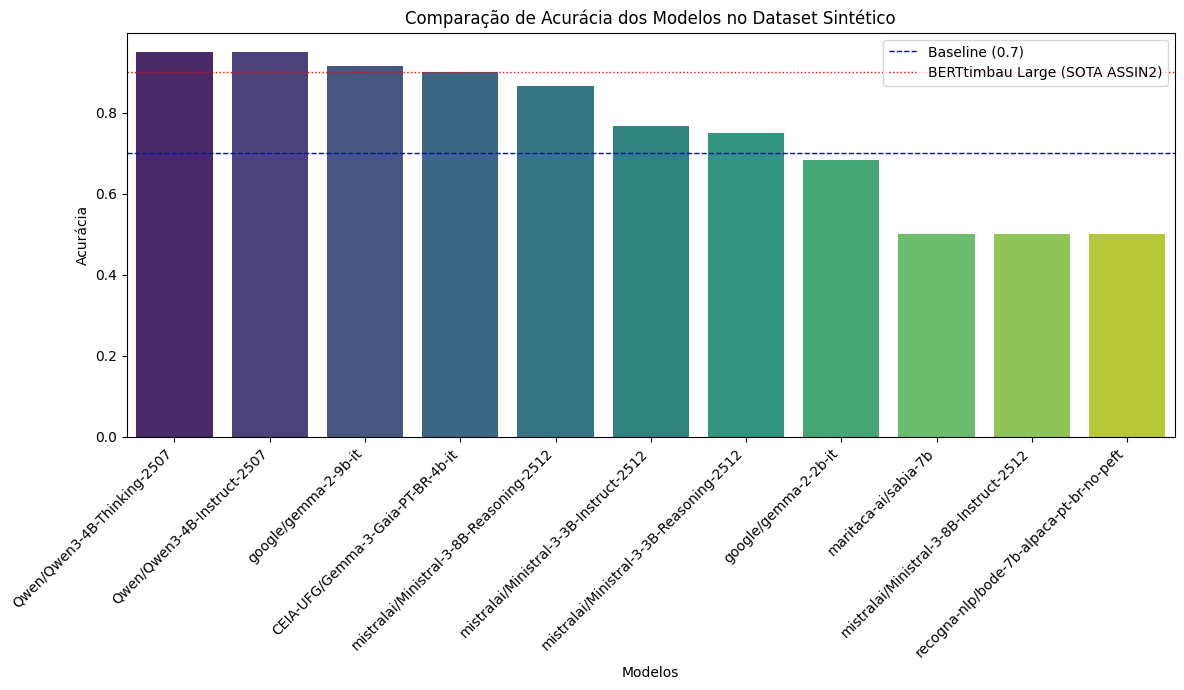

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Sort the extended DataFrame by accuracy for visualization
df_logs_sorted_extended = df_logs.sort_values(by='metrics_acurácia_df_sintetico', ascending=False)

# Define a custom color palette for highlighting 'Bertimbau'
# Generate viridis colors for all bars based on their sorted order
total_bars = len(df_logs_sorted_extended)
viridis_colors_map = sns.color_palette('viridis', n_colors=total_bars)


plt.figure(figsize=(12, 7))
sns.barplot(
    x='model',
    y='metrics_acurácia_df_sintetico',
    data=df_logs_sorted_extended,
    hue='model', # Assign x variable to hue to suppress FutureWarning
    palette=viridis_colors_map, # Use the custom color list
    legend=False # Set legend to False as suggested by FutureWarning
)

# Reference lines
plt.axhline(y=0.7, color='blue', linestyle='--', linewidth=1.0, label='Baseline (0.7)')
plt.axhline(y=0.9, color='red', linestyle=':', linewidth=1.0, label='BERTtimbau Large (SOTA ASSIN2)')

plt.xlabel('Modelos')
plt.ylabel('Acurácia')
plt.title('Comparação de Acurácia dos Modelos no Dataset Sintético') # Updated title
plt.xticks(rotation=45, ha='right')

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
|